[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter1_seminar_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Seminar 1: Forecast evaluation, scoring rules and combination

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 1; the slides give the definitions ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.
- The first code cell installs the `arch` package if it is missing.

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_1'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
# The arch package (Hansen's SPA test) is not preinstalled in Google Colab: pip install arch
import importlib.util, subprocess, sys
if importlib.util.find_spec('arch') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'arch'])

In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- Scores and tests of Chapter 1 (`dm_test`, `cw_test`, `mz_test`, `berkowitz_test`, `crps_normal`, `crps_t`, `pinball`, `interval_score`), data loaders, `garch_fit`, `combine_spf`, `load_forecasts`, and the functions of the solved tasks.

In [ ]:
import io
import urllib.error
from scipy import special
import statsmodels.api as sm
SEED = 2026
HICP_RO = ('prc_hicp_minr', 'M.RCH_A.TOTAL.RO')
RATE_RO = ('irt_st_m', 'M.IRT_M3.RO')
RATE_EA = ('irt_st_m', 'M.IRT_M3.EA')
SPF_URL = 'https://www.philadelphiafed.org/-/media/FRBP/Assets/Surveys-And-Data/survey-of-professional-forecasters/historical-data/SPFmicrodata.xlsx'
RTDSM_URL = 'https://www.philadelphiafed.org/-/media/FRBP/Assets/Surveys-And-Data/real-time-data/data-files/xlsx/routput_first_second_third.xlsx'
LOAD_API = 'https://api.energy-charts.info/public_power?country=ro&start={a}&end={b}'
LOAD_YEARS = (2023, 2024, 2025, 2026)
LOAD_END = '2026-09-30'
DGT_SPLIT = ('2000-01-01', '2012-12-31', '2026-09-18')
INFL_H, INFL_WIN, INFL_P = 12, 120, 3
INFL_EVAL = '2013-01-01'
BNR_TARGET = 2.5
AO_WIN, AO_LAGS, AO_EVAL = 60, 4, '1985-01-01'
FX_START, FX_EVAL = '2005-07-01', '2010-01-01'
LOAD_WIN, LOAD_RES, LOAD_EVAL = 364, 182, '2025-01-01'
TAUS = np.arange(1, 100) / 100
SPF_VAR, SPF_H = 'CPI', 6
SPF_EVAL = (1990, 2025)
SPF_WIN, SPF_MIN = 20, 8
MCS_ALPHA, BOOT_B, BLOCK = 0.1, 2000, 7
_FILES = {}
GDP_RO = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
GDP_EVAL = '2010-01-01'
FX_DAILY = ('2010-01-01', '2018-12-31', '2026-09-18')
SPF_U, SPF_UH = 'UNEMP', 4
PEAK_HOUR = 19
HORIZONS = (1, 3, 6, 12)


def get_bytes(url):
    """Download a public file once per session (no key)."""
    import hashlib
    import time
    if url in _FILES:
        return _FILES[url]
    cache = os.environ.get('ATS_CACHE')                 # optional local cache folder (not needed in Colab)
    path = os.path.join(cache, hashlib.md5(url.encode()).hexdigest()) if cache else None
    if path and os.path.exists(path):
        _FILES[url] = open(path, 'rb').read()
        return _FILES[url]
    for attempt in range(6):                            # the Energy-Charts API limits the request rate
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 (ATS course)'})
            _FILES[url] = urllib.request.urlopen(req, timeout=180).read()
            break
        except urllib.error.HTTPError as e:
            if e.code != 429 or attempt == 5:
                raise
            time.sleep(15 * (attempt + 1))
    if path:
        os.makedirs(cache, exist_ok=True)
        open(path, 'wb').write(_FILES[url])
    return _FILES[url]


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def pinball(y, q, tau):
    """Quantile (pinball) loss rho_tau(y - q) = (1{y < q} - tau)(q - y)."""
    return ((y < q).astype(float) - tau) * (q - y)


def interval_score(y, lo, hi, alpha):
    """Interval score of a central (1 - alpha) interval (Gneiting and Raftery 2007): width plus 2/alpha times misses."""
    return (hi - lo) + 2 / alpha * (lo - y) * (y < lo) + 2 / alpha * (y - hi) * (y > hi)


def crps_normal(y, mu, sigma):
    """CRPS of N(mu, sigma^2) at y (closed form)."""
    z = (y - mu) / sigma
    return sigma * (z * (2 * stats.norm.cdf(z) - 1) + 2 * stats.norm.pdf(z) - 1 / np.sqrt(np.pi))


def crps_t(y, mu, s, nu):
    """CRPS of a location-scale Student t (location mu, scale s, nu > 1 degrees of freedom) at y (closed form)."""
    z = (y - mu) / s
    term = (2 * np.sqrt(nu) / (nu - 1)) * special.beta(0.5, nu - 0.5) / special.beta(0.5, nu / 2) ** 2
    return s * (z * (2 * stats.t.cdf(z, nu) - 1) + 2 * stats.t.pdf(z, nu) * (nu + z ** 2) / (nu - 1) - term)


def hac_var(x, lags, kernel='bartlett', center=True):
    """Long-run variance of a series: Bartlett (Newey-West) or rectangular (truncated) kernel."""
    x = np.asarray(x, float)
    x = x - x.mean() if center else x
    T = len(x)
    v = x @ x / T
    for k in range(1, lags + 1):
        w = 1 - k / (lags + 1) if kernel == 'bartlett' else 1.0
        v += 2 * w * (x[k:] @ x[:-k]) / T
    return v


def dm_test(d, h=1, kernel='rect', lags=None):
    """Diebold-Mariano test of E[d] = 0 for the loss differential d (model 1 minus model 2) with the HAC variance
    (rectangular kernel with h - 1 lags as in Diebold and Mariano 1995; Bartlett if it is negative) and the
    Harvey-Leybourne-Newbold (1997) small-sample correction with Student t(T - 1) critical values."""
    d = np.asarray(d, float)
    d = d[~np.isnan(d)]
    T = len(d)
    L = h - 1 if lags is None else lags
    v = hac_var(d, L, kernel)
    used = kernel
    if v <= 0:
        v, used = hac_var(d, L, 'bartlett'), 'bartlett'
    dm = d.mean() / np.sqrt(v / T)
    k = np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T)
    hln = k * dm
    return {'T': T, 'dbar': float(d.mean()), 'dm': float(dm), 'p_dm': float(2 * stats.norm.sf(abs(dm))),
            'hln': float(hln), 'p_hln': float(2 * stats.t.sf(abs(hln), T - 1)), 'kernel': used}


def gw_test(d, Z, h=1):
    """Giacomini-White (2006) test of conditional equal predictive ability: E[Z_t d_{t+h}] = 0, Wald statistic
    T m' Omega^-1 m ~ chi2(q), with Omega the (uncentred) HAC covariance of Z_t d_{t+h} (h - 1 Bartlett lags)."""
    d = np.asarray(d, float)
    Z = np.column_stack([np.ones(len(d))] + [np.asarray(z, float) for z in Z])
    ok = ~np.isnan(d) & ~np.isnan(Z).any(axis=1)
    X = Z[ok] * d[ok, None]
    T, q = X.shape
    m = X.mean(axis=0)
    S = X.T @ X / T
    for k in range(1, h):
        G = X[k:].T @ X[:-k] / T
        S += (1 - k / h) * (G + G.T)
    stat = float(T * m @ np.linalg.solve(S, m))
    return {'T': int(T), 'q': int(q), 'stat': stat, 'p': float(stats.chi2.sf(stat, q))}


def cw_test(y, f_small, f_big, h=1):
    """Clark-West (2007) test for nested models: adjusted MSPE differential
    f_t = e_small^2 - [e_big^2 - (f_small - f_big)^2]; one-sided t test (H1: the larger model is better)."""
    e1, e2 = y - f_small, y - f_big
    f = e1 ** 2 - (e2 ** 2 - (f_small - f_big) ** 2)
    f = np.asarray(f, float)
    T = len(f)
    v = hac_var(f, max(h - 1, 0), 'bartlett')
    t = f.mean() / np.sqrt(v / T)
    return {'T': T, 'cw': float(t), 'p': float(stats.norm.sf(t))}


def mz_test(y, f, h=1):
    """Mincer-Zarnowitz regression y = a + b f + u with Newey-West standard errors (h - 1 lags, at least 1)
    and the Wald test of (a, b) = (0, 1)."""
    import statsmodels.api as sm
    X = sm.add_constant(np.asarray(f, float))
    m = sm.OLS(np.asarray(y, float), X).fit(cov_type='HAC', cov_kwds={'maxlags': max(h - 1, 1)})
    w = m.wald_test((np.eye(2), np.array([0.0, 1.0])), scalar=True)
    return {'a': float(m.params[0]), 'b': float(m.params[1]), 'se_a': float(m.bse[0]), 'se_b': float(m.bse[1]),
            'wald': float(w.statistic), 'p': float(w.pvalue), 'r2': float(m.rsquared)}


def encompassing_test(y, f1, f2, h=1):
    """Harvey-Leybourne-Newbold (1998) test of H0: forecast 1 encompasses forecast 2, d_t = e1_t (e1_t - e2_t),
    one-sided (H1: E d > 0, forecast 2 adds information), HLN-corrected statistic with t(T - 1)."""
    e1, e2 = y - f1, y - f2
    r = dm_test(e1 * (e1 - e2), h)
    r['p_one'] = float(stats.t.sf(r['hln'], r['T'] - 1))
    return r


def berkowitz_test(u):
    """Berkowitz (2001) LR test: z = Phi^-1(PIT) is i.i.d. N(0, 1) against an AR(1) with free mean and variance."""
    z = stats.norm.ppf(np.clip(np.asarray(u, float), 1e-10, 1 - 1e-10))
    y, x = z[1:], z[:-1]
    X = np.column_stack([np.ones(len(x)), x])
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    res = y - X @ b
    s2 = res @ res / len(y)
    ll1 = np.sum(stats.norm.logpdf(res, scale=np.sqrt(s2)))
    ll0 = np.sum(stats.norm.logpdf(y))
    lr = float(2 * (ll1 - ll0))
    return {'mu': float(b[0] / (1 - b[1])), 'rho': float(b[1]), 'sigma': float(np.sqrt(s2 / (1 - b[1] ** 2))),
            'lr': lr, 'p': float(stats.chi2.sf(lr, 3))}


def mcs(losses, alpha=MCS_ALPHA, B=BOOT_B, block=BLOCK, seed=SEED):
    """Model Confidence Set (Hansen, Lunde and Nason 2011) with the T_max statistic and a moving-block bootstrap:
    eliminate the model with the largest standardised loss differential until the equivalence test is not rejected.
    losses: T x m DataFrame. Returns the MCS p-value of every model and the set at level alpha."""
    L = np.asarray(losses, float)
    L = L[~np.isnan(L).any(axis=1)]
    T, m = L.shape
    rng = np.random.default_rng(seed)
    nb = int(np.ceil(T / block))
    idx = np.concatenate([np.arange(s, s + block) for s in rng.integers(0, T - block + 1, size=(B, nb)).ravel()])
    idx = idx.reshape(B, nb * block)[:, :T]
    Lb = L[idx].mean(axis=1)                          # B x m bootstrap means
    alive = list(range(m))
    pvals = {}
    p_run = 0.0
    while len(alive) > 1:
        Lm = L[:, alive].mean(axis=0)
        dbar = Lm - Lm.mean()                         # d_i. = loss of i minus the average loss of the set
        db = Lb[:, alive] - Lb[:, alive].mean(axis=1, keepdims=True)
        se = np.sqrt(((db - dbar) ** 2).mean(axis=0))
        t = dbar / se
        tb = ((db - dbar) / se).max(axis=1)
        p = float((tb > t.max()).mean())
        p_run = max(p_run, p)
        worst = alive[int(np.argmax(t))]
        pvals[worst] = p_run
        alive.remove(worst)
    pvals[alive[0]] = 1.0
    cols = list(losses.columns) if hasattr(losses, 'columns') else list(range(m))
    out = {cols[i]: pvals[i] for i in range(m)}
    return {'p': out, 'set': [c for c in cols if out[c] >= alpha]}


def spf_sheet(name):
    """One sheet of the SPF microdata file: YEAR, QUARTER, ID, INDUSTRY and the forecasts."""
    return pd.read_excel(io.BytesIO(get_bytes(SPF_URL)), sheet_name=name)


def us_cpi_quarterly():
    """US CPI (FRED CPIAUCSL), quarterly average, and the annualised quarter-on-quarter inflation rate in %."""
    c = read_fred('CPIAUCSL').dropna()
    n = c.resample('QS').count()
    p = c.resample('QS').mean()
    p = p[: n.index[-1] if n.iloc[-1] == 3 else n.index[-2]]           # drop the last quarter if incomplete
    p = p.asfreq('QS')                                                  # (October 2025 was not published: 2 months)
    pi = 100 * ((p / p.shift(1)) ** 4 - 1)
    return p, pi.dropna().rename('pi')


def ro_load_hourly():
    """Romanian hourly electricity load (MW), local time, 2023 to LOAD_END (Energy-Charts, ENTSO-E transparency data):
    the 15-minute values are averaged within each hour; a 24 x days table (DST days: 23 or 25 hours become 24)."""
    parts = []
    for y in LOAD_YEARS:
        b = min(f'{y}-12-31', LOAD_END)
        d = json.loads(get_bytes(LOAD_API.format(a=f'{y}-01-01', b=b)))
        load = [x for x in d['production_types'] if x['name'] == 'Load'][0]['data']
        parts.append(pd.Series(load, index=pd.to_datetime(d['unix_seconds'], unit='s', utc=True), dtype=float))
    s = pd.concat(parts).sort_index()
    s = s[~s.index.duplicated()].tz_convert('Europe/Bucharest')
    df = pd.DataFrame({'y': s.values, 'day': s.index.tz_localize(None).normalize(), 'hour': s.index.hour})
    tab = df.groupby(['day', 'hour'])['y'].mean().unstack('hour')
    tab = tab.interpolate(axis=1, limit_direction='both').interpolate(axis=0, limit_direction='both')
    return tab.loc[:LOAD_END]


def realtime_gdp():
    """US real GDP growth (annualised q/q, %): first, second, third release and the latest vintage (RTDSM)."""
    d = pd.read_excel(io.BytesIO(get_bytes(RTDSM_URL)), sheet_name='DATA', header=None)
    i = d.index[d.iloc[:, 0].astype(str).str.strip() == 'Date'][0]
    t = d.iloc[i + 1:, :5].copy()
    t.columns = ['date', 'first', 'second', 'third', 'latest']
    t = t.dropna(subset=['date'])
    t['date'] = pd.PeriodIndex(t['date'].astype(str).str.replace(':', '-'), freq='Q').to_timestamp()
    return t.set_index('date').apply(pd.to_numeric, errors='coerce')


def garch_filter(p, r, dist, garch=True, ma=True):
    """MA(1)-GARCH(1,1) filter: one-step means m_t and variances s2_t given r_1..r_{t-1}; p = (mu, theta, omega,
    alpha, beta[, nu]). Without GARCH the variance is constant (omega); without MA, theta = 0."""
    mu, th, om, al, be = p[:5]
    th = th if ma else 0.0
    n = len(r)
    m = np.empty(n)
    s2 = np.empty(n)
    e_prev, s2_prev = 0.0, np.var(r)
    for t in range(n):
        m[t] = mu + th * e_prev
        s2[t] = (om + al * e_prev ** 2 + be * s2_prev) if garch else om
        e_prev = r[t] - m[t]
        s2_prev = s2[t]
    return m, s2


def logdens(r, m, s2, dist, nu=None):
    """Log predictive density: Normal, or Student t with unit variance (scale sqrt((nu - 2)/nu))."""
    if dist == 'normal':
        return stats.norm.logpdf(r, m, np.sqrt(s2))
    sc = np.sqrt(s2 * (nu - 2) / nu)
    return stats.t.logpdf((r - m) / sc, nu) - np.log(sc)


def garch_fit(r, dist='t', garch=True, ma=True):
    """Gaussian or Student-t maximum likelihood of the MA(1)-GARCH(1,1) model (or its constant-variance version)."""
    r = np.asarray(r, float)
    v = np.var(r)

    def nll(q):
        p = list(q[:5]) + [None]
        nu = q[5] if dist == 't' else None
        if garch and q[3] + q[4] >= 0.9999:
            return 1e10
        m, s2 = garch_filter(q, r, dist, garch, ma)
        if np.any(s2 <= 0):
            return 1e10
        return -np.sum(logdens(r, m, s2, dist, nu))

    x0 = [r.mean(), 0.0, (0.05 * v if garch else v), (0.08 if garch else 0), (0.9 if garch else 0)] + ([8.0] if dist == 't' else [])
    b = [(None, None), (-0.9, 0.9), (1e-8, None), (0, 1 if garch else 0), (0, 1 if garch else 0)] + ([(2.05, 200)] if dist == 't' else [])
    res = optimize.minimize(nll, x0, method='L-BFGS-B', bounds=b)
    return res.x, -res.fun


def dgt_forecasts():
    """Diebold, Gunther and Tay (1998) re-run on the S&P 500: parameters estimated once on the first sample, one-day
    density forecasts on the second sample: i.i.d. Normal, MA(1)-GARCH(1,1)-Normal, MA(1)-GARCH(1,1)-t."""
    r = log_returns('sp500', DGT_SPLIT[0], DGT_SPLIT[2])
    est = r.loc[:DGT_SPLIT[1]]
    ev_mask = r.index > pd.Timestamp(DGT_SPLIT[1])
    out = {}
    for name, dist, garch in [('iid Normal', 'normal', False), ('GARCH-N', 'normal', True), ('GARCH-t', 't', True)]:
        p, ll = garch_fit(est.values, dist, garch, ma=garch)
        m, s2 = garch_filter(p, r.values, dist, garch, ma=garch)
        nu = p[5] if dist == 't' else None
        y = r.values[ev_mask]
        m, s2 = m[ev_mask], s2[ev_mask]
        if dist == 'normal':
            u = stats.norm.cdf(y, m, np.sqrt(s2))
            crps = crps_normal(y, m, np.sqrt(s2))
        else:
            sc = np.sqrt(s2 * (nu - 2) / nu)
            u = stats.t.cdf((y - m) / sc, nu)
            crps = crps_t(y, m, sc, nu)
        out[name] = {'params': [float(x) for x in p], 'loglik': float(ll), 'pit': u, 'logs': -logdens(y, m, s2, dist, nu),
                     'crps': crps, 'dens': np.exp(logdens(y, m, s2, dist, nu)), 'nu': None if nu is None else float(nu)}
    return r[ev_mask], out


def spf_panel(var=SPF_VAR, h=SPF_H):
    """Individual SPF forecasts of `var`{h} by survey (rows) and forecaster ID (columns), and the realised value of
    the target quarter (survey quarter + h - 2 quarters): annualised q/q CPI inflation (FRED CPIAUCSL)."""
    d = spf_sheet(var)
    col = f'{var}{h}'
    d['survey'] = pd.PeriodIndex.from_fields(year=d['YEAR'], quarter=d['QUARTER'], freq='Q')
    W = d.pivot_table(index='survey', columns='ID', values=col, aggfunc='mean')
    _, pi = us_cpi_quarterly()
    real = pi.copy()
    real.index = pd.PeriodIndex(real.index, freq='Q')
    target = W.index + (h - 2)
    y = pd.Series(real.reindex(target).values, index=W.index, name='y')
    return W, y


def combine_spf(W, y, win=SPF_WIN, minrec=SPF_MIN, lag=None, lam=(0.0, 0.25, 0.5, 0.75, 1.0)):
    """Combination schemes at each survey s (Genre et al. 2013): equal-weight mean, median, 10% trimmed mean,
    inverse-MSE performance weights over the last `win` surveys with a known outcome (at least `minrec` forecasts),
    their shrinkage towards equal weights with factor lambda, and the previous best forecaster."""
    lag = (SPF_H - 1) if lag is None else lag           # outcome of survey s - lag is known at survey s
    E = W.sub(y, axis=0)                                 # forecast errors
    out = []
    surveys = W.index
    for k, s in enumerate(surveys):
        f = W.loc[s].dropna()
        if len(f) < 5 or np.isnan(y.loc[s]):
            continue
        r = {'survey': s, 'y': y.loc[s], 'n': len(f), 'mean': f.mean(), 'median': f.median(),
             'trimmed 10%': stats.trim_mean(f.values, 0.1)}
        past = E.iloc[max(0, k - lag - win + 1):max(0, k - lag + 1)]
        cnt = past[f.index].notna().sum()
        mse = (past[f.index] ** 2).mean()
        ok = cnt[cnt >= minrec].index
        if len(ok) >= 3:
            inv = 1 / mse[ok]
            wp = inv / inv.sum()
            eq = pd.Series(1 / len(ok), index=ok)
            r['mean of eligible'] = f[ok].mean()
            for l in lam:
                r[f'shrink {l:.2f}'] = float(((l * wp + (1 - l) * eq) * f[ok]).sum())
            r['previous best'] = f[mse[ok].idxmin()]
            r['n_ok'] = len(ok)
        out.append(r)
    return pd.DataFrame(out).set_index('survey')


def ro_inflation_forecasts(h=INFL_H, win=INFL_WIN, p=INFL_P, first=INFL_EVAL):
    """Forecasts of Romanian HICP inflation h months ahead made at each origin t: no change (random walk), a direct
    AR(p) estimated by OLS on a rolling window, the BNR target and the equal-weight average of AR and no change."""
    pi = read_eurostat(*HICP_RO).astype(float)
    pi.index = pd.DatetimeIndex(pi.index)
    x = pi.values
    rows = []
    for i in range(len(x)):
        t = pi.index[i]
        if t < pd.Timestamp(first) or i + h >= len(x):
            continue
        lo = i - win
        Y, X = [], []
        for j in range(lo + p - 1, i - h + 1):
            Y.append(x[j + h])
            X.append([1.0] + [x[j - k] for k in range(p)])
        b = np.linalg.lstsq(np.array(X), np.array(Y), rcond=None)[0]
        f_ar = float(np.array([1.0] + [x[i - k] for k in range(p)]) @ b)
        rows.append({'origin': t, 'target': pi.index[i + h], 'y': x[i + h], 'rw': x[i], 'ar': f_ar,
                     'target_fc': BNR_TARGET, 'comb': 0.5 * (f_ar + x[i])})
    return pi, pd.DataFrame(rows).set_index('target')


def load_forecasts(win=LOAD_WIN, res_win=LOAD_RES, first=LOAD_EVAL):
    """Day-ahead forecasts of the 24 hourly loads of day d + 1 with data up to day d:
    naive (day d), weekly naive (day d - 6), mean of the last four same weekdays, the expert ARX model of
    Ziel and Weron (2018) for each hour (y_{d,h}, y_{d-1,h}, y_{d-6,h}, min_d, max_d, y_{d,24}, Monday, Saturday,
    Sunday; rolling window `win` days) and the average of ARX and the four-week mean. Quantiles: point forecast plus
    empirical quantiles of the model's last `res_win` errors at the same hour."""
    Y = ro_load_hourly() / 1000.0                              # GW
    days = Y.index
    A = Y.values
    nD = len(days)
    dow = np.array([d.dayofweek for d in days])
    start = int(np.searchsorted(days, pd.Timestamp(first)))
    names = ['naive day', 'naive week', 'mean 4 weeks', 'expert ARX', 'ARX + mean 4 weeks']
    P = {n: np.full((nD, 24), np.nan) for n in names}
    for d1 in range(28, nD):
        d = d1 - 1
        P['naive day'][d1] = A[d]
        P['naive week'][d1] = A[d1 - 7]
        P['mean 4 weeks'][d1] = A[[d1 - 7, d1 - 14, d1 - 21, d1 - 28]].mean(axis=0)
    mins, maxs, last = A.min(axis=1), A.max(axis=1), A[:, 23]
    for d1 in range(max(start - res_win - 1, win + 8), nD):
        rows = np.arange(d1 - win, d1)                       # targets in the window
        rows = rows[rows >= 8]
        for h in range(24):
            X = np.column_stack([np.ones(len(rows)), A[rows - 1, h], A[rows - 2, h], A[rows - 7, h], mins[rows - 1],
                                 maxs[rows - 1], last[rows - 1], dow[rows] == 0, dow[rows] == 5, dow[rows] == 6])
            b = np.linalg.lstsq(X, A[rows, h], rcond=None)[0]
            x = np.r_[1.0, A[d1 - 1, h], A[d1 - 2, h], A[d1 - 7, h], mins[d1 - 1], maxs[d1 - 1], last[d1 - 1],
                      dow[d1] == 0, dow[d1] == 5, dow[d1] == 6]
            P['expert ARX'][d1, h] = x @ b
    P['ARX + mean 4 weeks'] = 0.5 * (P['expert ARX'] + P['mean 4 weeks'])
    Q = {}
    for n in names:
        E = A - P[n]
        Q[n] = np.full((nD, 24, len(TAUS)), np.nan)
        for d1 in range(start, nD):
            R = E[d1 - res_win:d1]
            Q[n][d1] = P[n][d1][:, None] + np.nanquantile(R, TAUS, axis=0).T
    return days[start:], A[start:], {n: P[n][start:] for n in names}, {n: Q[n][start:] for n in names}


def a1_optimal_forecasts():
    """Y ~ Exponential(1): optimal forecasts under squared, absolute and pinball (tau = 0.9) loss and their risks
    (risk of the pinball loss at the 0.9-quantile: tau * E[Y] - E[Y 1{Y < q}] ... computed exactly by integration)."""
    from scipy import integrate
    q = float(np.log(10))
    risk_pin = integrate.quad(lambda y: pinball(np.array(y), q, 0.9) * np.exp(-y), 0, 60, points=[q])[0]
    return {'mean': 1.0, 'median': float(np.log(2)), 'q90': q, 'risk_sq': 1.0, 'risk_abs': float(np.log(2)),
            'risk_pin': float(risk_pin)}


def a3_scores(y=3.5, mu=2.0, sigmas=(1.0, 0.5)):
    """Log score (negative log density) and CRPS of N(mu, s^2) forecasts at the outcome y."""
    out = {}
    for s in sigmas:
        out[f'{s}'] = {'z': (y - mu) / s, 'logs': float(-stats.norm.logpdf(y, mu, s)), 'crps': float(crps_normal(y, mu, s))}
    return out


def a5_dm_by_hand(T=40, h=2, dbar=0.30, g0=1.2, g1=0.4):
    """DM with the rectangular HAC variance (h - 1 = 1 lag) and the HLN correction."""
    v = g0 + 2 * g1
    dm = dbar / np.sqrt(v / T)
    k = np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T)
    return {'v': v, 'se': float(np.sqrt(v / T)), 'dm': float(dm), 'k': float(k), 'hln': float(k * dm),
            'p_dm': float(2 * stats.norm.sf(dm)), 'p_hln': float(2 * stats.t.sf(k * dm, T - 1)), 'crit': float(stats.t.ppf(0.975, T - 1))}


def a7_bates_granger(s1=2.0, s2=3.0, rho=0.4):
    """Optimal weight on forecast 1, the combined error variance, and equal weights."""
    c = rho * s1 * s2
    D = s1 ** 2 + s2 ** 2 - 2 * c
    w = (s2 ** 2 - c) / D
    return {'cov': c, 'D': D, 'w': float(w), 'var_opt': float((s1 ** 2 * s2 ** 2 - c ** 2) / D),
            'var_eq': float(0.25 * (s1 ** 2 + s2 ** 2 + 2 * c)), 'var1': s1 ** 2}


def b1_ro_gdp(save_it=True):
    """Romanian real GDP growth (q/q, %), one-step forecasts made recursively: AR(1), historical mean, no change;
    DM-HLN under squared and absolute loss, with and without 2020."""
    g = read_eurostat(*GDP_RO)
    y = (100 * np.log(g).diff()).dropna()
    rows = []
    for i in range(20, len(y) - 1):
        t1 = y.index[i + 1]
        if t1 < pd.Timestamp(GDP_EVAL):
            continue
        x = y.values[:i + 1]
        X = np.column_stack([np.ones(len(x) - 1), x[:-1]])
        b = np.linalg.lstsq(X, x[1:], rcond=None)[0]
        rows.append({'date': t1, 'y': y.values[i + 1], 'AR(1)': b[0] + b[1] * x[-1], 'mean': x.mean(), 'no change': x[-1]})
    F = pd.DataFrame(rows).set_index('date')
    fig, ax = plt.subplots(figsize=(10.5, 3.8))
    ax.plot(F.index, F['y'], color=st.DarkText, lw=1.5, label='real GDP growth, Romania (q/q, %)')
    ax.plot(F.index, F['AR(1)'], color=st.MainBlue, lw=1.2, label='AR(1), recursive')
    ax.plot(F.index, F['mean'], color=st.Forest, lw=1.2, label='historical mean')
    ax.plot(F.index, F['no change'], color=st.IDAred, lw=1.0, ls='--', label='no change')
    ax.set_ylabel('%')
    st.legend_outside_bottom(ax, ncol=4, y=-0.15)
    save('ch1_sem_b1', save_it)
    out = {'n': int(len(F)), 'first': str(F.index[0].date()), 'last': str(F.index[-1].date())}
    for nm, mask in [('all', np.ones(len(F), bool)), ('ex2020', F.index.year != 2020)]:
        G = F[mask]
        r = {}
        for m in ('AR(1)', 'mean', 'no change'):
            e = G['y'] - G[m]
            r[m] = {'rmse': float(np.sqrt(np.mean(e ** 2))), 'mae': float(np.mean(np.abs(e)))}
        for m in ('mean', 'no change'):
            r[f'dm_sq_{m}'] = dm_test((G['y'] - G['AR(1)']) ** 2 - (G['y'] - G[m]) ** 2, 1)
            r[f'dm_abs_{m}'] = dm_test(np.abs(G['y'] - G['AR(1)']) - np.abs(G['y'] - G[m]), 1)
        r['n'] = int(len(G))
        out[nm] = r
    return out


def b3_eurron_density(save_it=True):
    """EUR/RON daily log returns (BNR reference rate): i.i.d. Normal against GARCH(1,1)-t density forecasts,
    parameters estimated once on 2010-2018; PIT, Berkowitz test, log score, CRPS, DM on the scores."""
    s = read_reference_rate('EUR', start=FX_DAILY[0], end=FX_DAILY[2])
    r = (100 * np.log(s).diff()).dropna()
    r = r[r != 0]
    ev = r.index > pd.Timestamp(FX_DAILY[1])
    est = r[~ev].values
    out = {'n_eval': int(ev.sum()), 'n_est': int((~ev).sum())}
    F = {}
    for name, dist, garch in [('iid Normal', 'normal', False), ('GARCH-t', 't', True)]:
        p, _ = garch_fit(est, dist, garch, ma=False)
        m, s2 = garch_filter(p, r.values, dist, garch, ma=False)
        y, m, s2 = r.values[ev], m[ev], s2[ev]
        nu = p[5] if dist == 't' else None
        if dist == 'normal':
            u, cr = stats.norm.cdf(y, m, np.sqrt(s2)), crps_normal(y, m, np.sqrt(s2))
        else:
            sc = np.sqrt(s2 * (nu - 2) / nu)
            u, cr = stats.t.cdf((y - m) / sc, nu), crps_t(y, m, sc, nu)
        ls = -logdens(y, m, s2, dist, nu)
        F[name] = (u, ls, cr)
        bt = berkowitz_test(u)
        out[name] = {'logs': float(ls.mean()), 'crps': float(cr.mean()), 'berk_lr': bt['lr'], 'berk_p': bt['p'],
                     'tails': float(np.mean((u < 0.05) | (u > 0.95))), 'nu': None if nu is None else float(nu),
                     'ab': None if not garch else float(p[3] + p[4])}
    out['dm_logs'] = dm_test(F['GARCH-t'][1] - F['iid Normal'][1], 1)
    out['dm_crps'] = dm_test(F['GARCH-t'][2] - F['iid Normal'][2], 1)
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
    for ax, (nm, c) in zip(axs, [('iid Normal', st.IDAred), ('GARCH-t', st.MainBlue)]):
        ax.hist(F[nm][0], bins=20, range=(0, 1), density=True, color=c, alpha=0.85, label=nm)
        ax.axhline(1, color=st.DarkText, lw=0.8, ls='--')
        ax.set_xlabel('PIT')
        st.legend_outside_bottom(ax, ncol=1, y=-0.22)
    axs[0].set_ylabel('density')
    plt.tight_layout()
    save('ch1_sem_b3', save_it)
    return out

# Part A: derivations and computations on paper

- Do each derivation on paper first; then check it with the code.

## A1 [Solved]: optimal forecasts of an exponential variable

**Context.** $Y \sim$ Exponential(1).

1. Derive the optimal forecast under the squared, the absolute and the pinball loss with $\tau = 0.9$.
2. Give the minimum expected loss under the squared and the absolute loss.
3. A forecaster reports the median and is judged by RMSE: compute the excess expected squared loss.

**Report:** three forecasts, two risks, one excess loss.

In [8]:
# Solution
r = a1_optimal_forecasts()
print({k: round(v, 4) for k, v in r.items()})
print('excess loss of the median:', round((1 - np.log(2)) ** 2, 4))

{'mean': 1.0, 'median': 0.6931, 'q90': 2.3026, 'risk_sq': 1.0, 'risk_abs': 0.6931, 'risk_pin': 0.2303}
excess loss of the median: 0.0942


**Interpretation of the result.** Mean 1, median 0.693, 0.9-quantile 2.303; reporting the median under squared loss costs $(1 - \ln 2)^2 = 0.094$.

## A2 [Proposed]: the optimal forecast under LinEx loss

**Context.** $L(e) = b[e^{ae} - ae - 1]$, $e = y - x$; $Y \sim N(\mu, \sigma^2)$. Model: A1.

1. Derive the first-order condition and solve it for $x$.
2. Compute $x^*$ for $\mu = 2$, $\sigma = 1.5$, $a = \pm 0.5$.
3. Explain why a rational forecaster with this loss fails the Mincer–Zarnowitz test.

**Report:** one formula, two numbers, two sentences.

In [ ]:
# Your code here


## A3 [Solved]: log score and CRPS of two Normal forecasts

**Context.** Forecasts $N(2, 1)$ and $N(2, 0.5^2)$; outcome $y = 3.5$.

1. Compute $z$, the log score and the CRPS of each forecast.
2. Which forecast wins under each score?
3. Prove that the log score is proper.

**Report:** a table of four scores, one sentence, a two-line proof.

In [10]:
# Solution
print(pd.DataFrame(a3_scores()).round(3))

        1.0    0.5
z     1.500  3.000
logs  2.044  4.726
crps  0.994  1.218


**Interpretation of the result.** The wider forecast wins under both scores; the log score more than doubles for the sharp forecast, the CRPS rises by about a fifth.

## A4 [Proposed]: an improper score and the interval score

**Context.** $Y \sim N(0, 1)$, forecasts $N(0, s^2)$; linear score $-f(y)$. Model: A3.

1. Show that $\mathbb{E} f(Y) = [2\pi(1 + s^2)]^{-1/2}$ and evaluate it for $s = 0.5, 1, 2$.
2. Explain why the linear score is improper.
3. Compute the interval score of the 90% interval $[1, 4]$ for $y = 3, 5, -1$.

**Report:** three expectations, one sentence, three scores.

In [ ]:
# Your code here


## A5 [Solved]: the Diebold–Mariano test by hand

**Context.** $h = 2$, $P = 40$, $\bar d = 0.30$, $\hat\gamma_0 = 1.2$, $\hat\gamma_1 = 0.4$.

1. Compute the long-run variance (rectangular kernel, $h - 1$ lags), the standard error and DM.
2. Apply the HLN correction and compare with $t_{39}$.
3. What would the i.i.d. variance have concluded?

**Report:** two statistics, two $p$-values, one sentence.

In [12]:
# Solution
print({k: round(v, 4) for k, v in a5_dm_by_hand().items()})

{'v': 2.0, 'se': 0.2236, 'dm': 1.3416, 'k': 0.9624, 'hln': 1.2912, 'p_dm': 0.1797, 'p_hln': 0.2042, 'crit': 2.0227}


**Interpretation of the result.** DM = 1.34, HLN = 1.29 ($p$ = 0.20): no evidence that forecast 2 is better.

## A6 [Proposed]: Clark–West by hand

**Context.** Random walk nested in an AR model; $P = 100$; $\overline{e_1^2} = 1.00$, $\overline{e_2^2} = 0.98$, $\overline{(\hat y_1 - \hat y_2)^2} = 0.06$; standard deviations of $f_t$ and $d_t$: 0.5. Model: A5.

1. Compute the naive DM statistic.
2. Compute the Clark–West statistic.
3. Explain the adjustment.

**Report:** two statistics, two $p$-values, two sentences.

In [ ]:
# Your code here


## A7 [Solved]: Bates–Granger weights

**Context.** $\sigma_1 = 2$, $\sigma_2 = 3$, $\rho = 0.4$.

1. Compute the optimal weight on forecast 1.
2. Compute the combined variance.
3. Compute the variance with equal weights.

**Report:** one weight, two variances, one sentence.

In [14]:
# Solution
print({k: round(v, 4) for k, v in a7_bates_granger().items()})

{'cov': 2.4, 'D': 8.2, 'w': 0.8049, 'var_opt': 3.6878, 'var_eq': 4.45, 'var1': 4.0}


**Interpretation of the result.** $w^* = 0.805$, combined variance 3.69 < 4; equal weights give 4.45, worse than forecast 1 alone.

## A8 [Proposed]: the cost of estimated weights

**Context.** $\sigma_1^2 = 1$, $\sigma_2^2 = 1.1$, $\rho = 0.5$, $n = 40$. Model: A7.

1. Show that $\mathrm{MSE}(w) = \mathrm{MSE}(w^*) + (w - w^*)^2D$.
2. Compute $w^*$, $D$ and the gain over $w = 1/2$.
3. Compare the expected estimation loss with the gain.

**Report:** one identity, three numbers, one conclusion.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: forecasting Romanian GDP growth

**Question.** Does an AR(1) forecast Romanian quarterly GDP growth better than the historical mean or no change, and does the answer depend on the loss and on 2020?

1. Compute recursive one-step forecasts and report RMSE and MAE.
2. Test AR(1) against each benchmark with DM–HLN under squared and absolute loss.
3. Repeat the tests without 2020.
4. Interpretation: is AR(1) better than the mean, and better than no change?

**Report:** a table of RMSE and MAE, eight HLN statistics with $p$-values, one sentence.

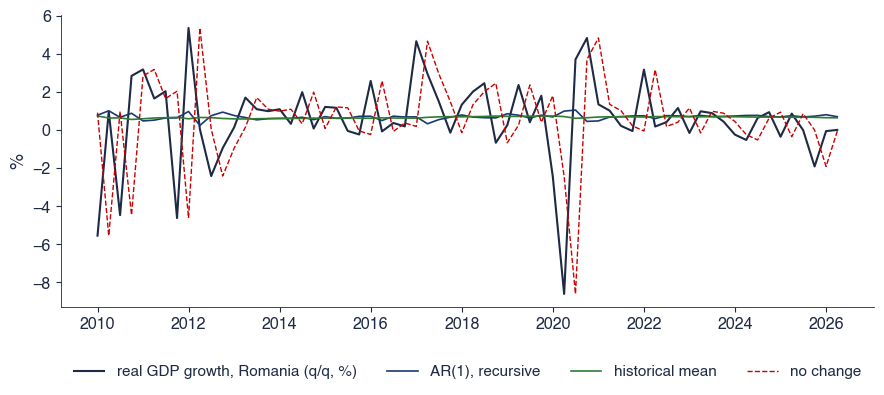

all {'AR(1)': {'rmse': 2.2556915757311744, 'mae': 1.476736397397668}, 'mean': {'rmse': 2.2445557522990116, 'mae': 1.4788539013731516}, 'no change': {'rmse': 3.2271343177854916, 'mae': 2.123255564895081}}
{'dm_sq_mean': (0.43, 0.671), 'dm_abs_mean': (-0.12, 0.908), 'dm_sq_no change': (-1.88, 0.065), 'dm_abs_no change': (-2.58, 0.012)}
ex2020 {'AR(1)': {'rmse': 1.8309898138549603, 'mae': 1.2535224177178896}, 'mean': {'rmse': 1.8350389514446224, 'mae': 1.2556344431840911}, 'no change': {'rmse': 2.7792344604703785, 'mae': 1.8759141917454982}}
{'dm_sq_mean': (-0.2, 0.843), 'dm_abs_mean': (-0.12, 0.902), 'dm_sq_no change': (-2.55, 0.013), 'dm_abs_no change': (-3.06, 0.003)}


In [16]:
# Solution
b1 = b1_ro_gdp(save_it=False)
for tag in ('all', 'ex2020'):
    print(tag, {m: b1[tag][m] for m in ('AR(1)', 'mean', 'no change')})
    print({k: (round(v['hln'], 2), round(v['p_hln'], 3)) for k, v in b1[tag].items() if k.startswith('dm_')})

**Interpretation of the result.** AR(1) and the mean are indistinguishable; both beat no change, more clearly under absolute loss and without 2020.

## B2 [Proposed]: combining SPF unemployment forecasts

**Question.** Can any combination of the individual SPF unemployment forecasts beat the simple mean two quarters ahead? Model: B1, A7.

1. Build the mean, median, 10% trimmed mean, inverse-MSE weights, their 50% shrinkage and the previous best (`combine_spf`).
2. Report RMSE relative to the mean and DM–HLN with $h = 3$.
3. Run the Mincer–Zarnowitz test for the mean, with and without 2020.
4. Interpretation: is the puzzle confirmed, and is the mean efficient?

**Report:** six relative RMSEs, five HLN statistics, two MZ tests, one sentence.

In [ ]:
# Your code here


## B3 [Solved]: density forecasts of EUR/RON

**Question.** Is a GARCH(1,1)-$t$ density forecast of daily EUR/RON returns calibrated, and is it better than an i.i.d. Normal forecast?

1. Fit both models on 2010–2018 and compute one-day PITs on 2019–2026.
2. Plot the PIT histograms, run the Berkowitz test, report the share outside $[0.05, 0.95]$.
3. Compute the average log score and CRPS and test their differences with DM–HLN.
4. Interpretation: can the better-scoring model still be miscalibrated?

**Report:** two histograms, two Berkowitz tests, two shares, four scores, two HLN statistics, one sentence.

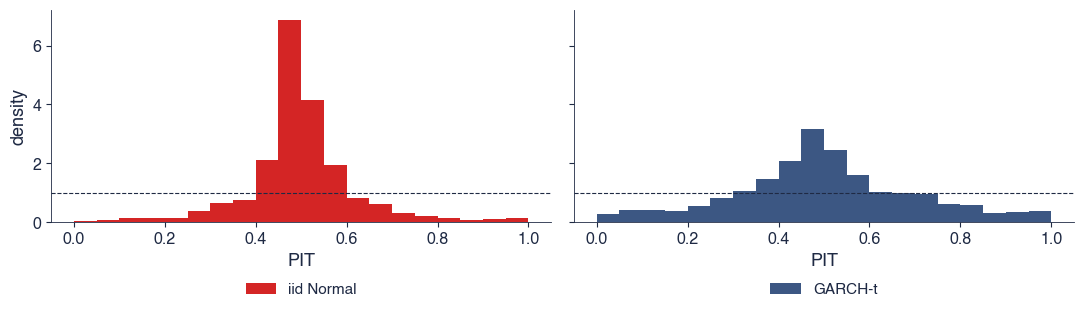

iid Normal {'logs': -0.43127272866844685, 'crps': 0.06880626797472823, 'berk_lr': 1441.8133351549195, 'berk_p': 0.0, 'tails': 0.01090909090909091, 'nu': None, 'ab': None}
GARCH-t {'logs': -1.224152403243565, 'crps': 0.04419140780971223, 'berk_lr': 538.5748447915194, 'berk_p': 2.0812566803250296e-116, 'tails': 0.03272727272727273, 'nu': 4.862325330774704, 'ab': 0.9998992789190854}
HLN log score: -49.3  HLN CRPS: -56.9


In [18]:
# Solution
b3 = b3_eurron_density(save_it=False)
for k in ('iid Normal', 'GARCH-t'):
    print(k, b3[k])
print('HLN log score:', round(b3['dm_logs']['hln'], 1), ' HLN CRPS:', round(b3['dm_crps']['hln'], 1))

**Interpretation of the result.** GARCH-$t$ wins every score, yet both are miscalibrated: EUR/RON has been much calmer since 2019, so the densities fixed in 2018 are too wide.

## B4 [Proposed]: SPF GDP forecasts and data vintages

**Question.** Does the accuracy and the efficiency of the SPF next-quarter GDP forecast depend on the vintage? Model: B1.

1. Compute the RMSE of the SPF mean against the first, second, third release and the latest vintage.
2. Run the Mincer–Zarnowitz test against each vintage.
3. Recompute the RMSE without 2020.
4. Interpretation: which vintage should a pre-registered evaluation use?

**Report:** four RMSEs, four MZ tests, two RMSEs without 2020, one sentence.

In [ ]:
# Your code here


## B5 [Proposed]: load quantiles at the evening peak

**Question.** Are the 90% load intervals for 19:00–20:00 calibrated, and does the expert ARX beat the weekly naive in interval score? Model: B3.

1. Compute the 5%, 50% and 95% quantile forecasts of both models at the peak hour (`load_forecasts`).
2. Report coverage, tail shares, width and interval score.
3. Test the interval-score difference with DM–HLN.
4. Interpretation: is the narrower interval also the better one?

**Report:** two coverages, four tail shares, two widths, two interval scores, one HLN statistic, one sentence.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: a pre-registered evaluation by horizon

**Question.** Does a direct AR(3) beat no change for Romanian inflation at some horizon, after a Holm correction? Model: B1.

1. Write the pre-registration (target, horizons, loss, benchmark, test, correction) before computing anything.
2. Compute the relative RMSE and DM–HLN for $h = 1, 3, 6, 12$ (`ro_inflation_forecasts(h=...)`).
3. Apply the Holm correction.
4. Interpretation: what would you have reported looking only at the best horizon?

**Report:** a five-line plan, four relative RMSEs, eight $p$-values, a project plan.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant answered:

- (a) for h = 4 use Newey–West with 4 lags; the HLN correction makes DM more liberal in small samples;
- (b) for a point forecast the CRPS equals the absolute error;
- (c) expected shortfall is elicitable because it is the mean of the tail;
- (d) to compare an AR model with the random walk it nests, use DM with Normal critical values;
- (e) a U-shaped PIT histogram means the predictive distribution is too wide;
- (f) the 90% MCS contains the best model with probability at least 90% asymptotically;
- (g) with sigma1 = 2, sigma2 = 3, rho = 0.4 the optimal weight on forecast 1 is 0.6.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** seven verdicts with one line of justification each.

In [ ]:
# Your code here
